In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os

sys.path.insert(1,'../')

from VI_solvers.rad_vi import RadVI 
from VI_solvers.laplace_approx import laplace_from_potential
from VI_solvers.gaussian_fbvi import Gaussian_FBVI

from utils.elliptical_distributions import MultivariateGaussian, MultivariateLaplace, MultivariateStudent, MultivariateLogistic 
from utils.transport_maps import GaussianToLaplaceOTMap, GaussianToLogisticOTMap, student_t_map
from utils.wasserstein_distance import w2_squared_radial_from_points

In [2]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams.update({"font.family": "serif", "font.serif": "Computer Modern"})

np.random.seed(1)

if not os.path.exists('plots/convergence'):
    os.makedirs('plots/convergence')

In [3]:
### List of alpha values to test
alpha_list = [1, 0.1, 0.01]

In [4]:
### Define target distribution
dim = 50

target_mean = np.zeros((dim, 1))
target_cov  = np.eye(dim)

target_distribution_gaussian = MultivariateGaussian(target_mean, target_cov)
V_gaussian                   = lambda x: target_distribution_gaussian.potential(x)
gradV_gaussian               = lambda x: target_distribution_gaussian.grad_potential(x)
hessV_gaussian               = lambda x: target_distribution_gaussian.hess_potential(x)

In [5]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate  = 7e-3
n_iterations   = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

### Define true optimal transport map
radial_map_gaussian = lambda r: r

In [6]:
radvi_gaussian_history = []

for alpha in alpha_list:

    RadVI_gaussian = RadVI(truncation=truncation, 
                        mesh=mesh, 
                        dim=dim, 
                        alpha=alpha, 
                        isotropic=True,
                        V=V_gaussian,
                        grad_V=gradV_gaussian, 
                        mean=target_mean, 
                        covariance=target_cov,
                        N_mc=n_samples_mc,
                        radial_ot_map=radial_map_gaussian)

    RadVI_gaussian.fit(learning_rate=learning_rate,
                       num_iterations=n_iterations, 
                       sample_size=n_samples_sgd,
                       compute_wasserstein=True,
                       print_freq=2500,
                       log_w2_freq=10)

    radvi_gaussian_history.append(RadVI_gaussian.wasserstein_history)


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 1
• Num. basis (J)  : 8
• Whitening       : No

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Computing Wasserstein distance every 10 iterations

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting radVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.1
• Num. basis (J)  : 8
• Whitening       : No

Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 10000
• Sample size     : 1

## Plot $W_2^2$ Convergence of radVI

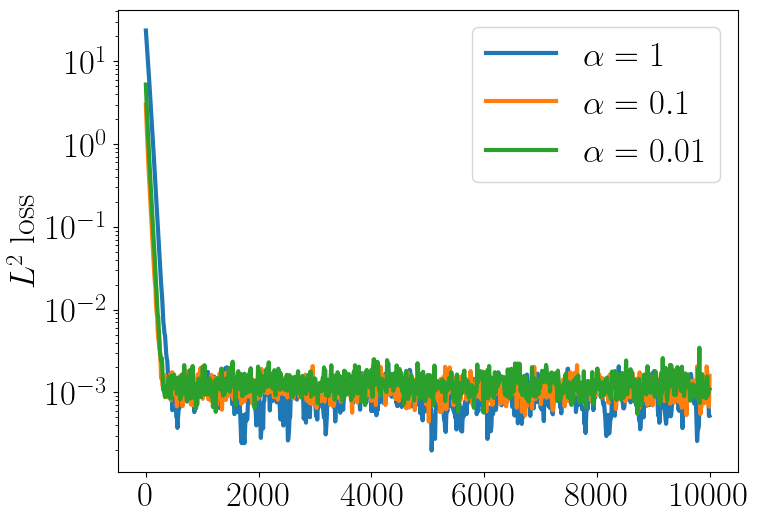

In [7]:
iterations_gaussian = np.arange(0, len(RadVI_gaussian.wasserstein_history)*10, 10)

plt.figure(figsize=(8,6))
for i, alpha in enumerate(alpha_list):
    plt.semilogy(iterations_gaussian, radvi_gaussian_history[i], label=fr'$\alpha={alpha}$',linewidth=3)

plt.ylabel(r'$L^2$ loss', fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(markerscale=7,fontsize=25)
plt.savefig(f'plots/convergence/isotropic_convergence_dim{dim}_alpha_robustness.pdf', dpi=300, bbox_inches='tight')
plt.show()